# 04b — Học Bán giám sát (Semi-Supervised)

So sánh Supervised-only vs Self-Training vs Label Spreading  
ở các tỷ lệ nhãn: **5%, 10%, 20%, 30%**.

**Đánh giá:**
- Learning curve (F1 / Accuracy / PR-AUC) theo % nhãn
- Phân tích pseudo-label sai (FN / FP trên dữ liệu unlabeled)
- Phân tích rủi ro: khi nào semi-supervised tốt hơn / tệ hơn supervised-only

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src import load_params
from src.data.loader import load_raw_data
from src.data.cleaner import run_cleaning_pipeline
from src.models.semi_supervised import run_semi_supervised

params = load_params()

## Chuẩn bị dữ liệu

Cùng pipeline tiền xử lý như notebook 04 (scaling, **không** SMOTE — semi-supervised tự xử lý nhãn thiếu).

In [2]:
df = load_raw_data(params)
prep = run_cleaning_pipeline(df, params)

print(f"X_train shape: {prep['X_train'].shape}")
print(f"X_test  shape: {prep['X_test'].shape}")

[LOADER] Đọc thành công: 920 dòng × 16 cột

TIỀN XỬ LÝ DỮ LIỆU
[CLEANER] Xử lý missing xong. Còn thiếu: 0
[CLEANER] Nhị phân hóa target: {1: 509, 0: 411}
[CLEANER] Mã hóa 7 biến phân loại
[CLEANER] Tách train/test: Train=736, Test=184
  Train: {1: 407, 0: 329}
  Test:  {1: 102, 0: 82}
[CLEANER] Chuẩn hóa 6 biến số (StandardScaler)
[CLEANER] Chuẩn hóa 6 biến số (StandardScaler)
[CLEANER] SMOTE: 736 → 814 mẫu
  Phân bố sau: {1: 407, 0: 407}
[CLEANER] Đã lưu dữ liệu processed → c:\KHMT\BTL-DATAMINING\data/processed
X_train shape: (736, 13)
X_test  shape: (184, 13)


## Chạy thực nghiệm bán giám sát

3 phương pháp × 4 tỷ lệ nhãn = 12 thí nghiệm  
Kết quả: Learning curve + Bảng so sánh + Phân tích pseudo-label sai + Phân tích rủi ro.


THỰC NGHIỆM BÁN GIÁM SÁT

──────────────────────────────────────────────────
TỶ LỆ NHÃN: 5%
──────────────────────────────────────────────────
  Tỷ lệ 5%: có nhãn 36/736

  [A] Supervised-only (36 mẫu):


c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


    Acc=0.8098, F1=0.8357, PR-AUC=0.9084, Time=0.21s

  [B] Self-Training (pseudo-label, threshold=0.75):


c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelfTrainingClassifier was fitted without feature names
  warnings.warn(
c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelfTrainingClassifier was fitted without feature names
  warnings.warn(
c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LabelSpreading was fitted without feature names
  warnings.warn(
c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LabelSpreading was fitted without feature names
  warnings.warn(


    Acc=0.7500, F1=0.7982, PR-AUC=0.8699, Time=3.93s
    Pseudo-label: 700 mẫu, đúng 508 (72.6%), sai 192
    Pseudo-label sai: FN=46 (bỏ sót bệnh), FP=111 (báo nhầm)

  [C] Label Spreading (kernel=rbf, gamma=20):
    Acc=0.7283, F1=0.7549, PR-AUC=0.7744, Time=0.02s

──────────────────────────────────────────────────
TỶ LỆ NHÃN: 10%
──────────────────────────────────────────────────
  Tỷ lệ 10%: có nhãn 72/736

  [A] Supervised-only (72 mẫu):


...

    Acc=0.7717, F1=0.8142, PR-AUC=0.8822, Time=4.49s
    Pseudo-label: 590 mẫu, đúng 418 (70.8%), sai 172
    Pseudo-label sai: FN=17 (bỏ sót bệnh), FP=73 (báo nhầm)

  [C] Label Spreading (kernel=rbf, gamma=20):
    Acc=0.7446, F1=0.7751, PR-AUC=0.8070, Time=0.01s

──────────────────────────────────────────────────
TỶ LỆ NHÃN: 30%
──────────────────────────────────────────────────
  Tỷ lệ 30%: có nhãn 220/736

  [A] Supervised-only (220 mẫu):


c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


    Acc=0.8098, F1=0.8357, PR-AUC=0.9007, Time=0.24s

  [B] Self-Training (pseudo-label, threshold=0.75):


c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelfTrainingClassifier was fitted without feature names
  warnings.warn(
c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelfTrainingClassifier was fitted without feature names
  warnings.warn(
c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LabelSpreading was fitted without feature names
  warnings.warn(
c:\KHMT\BTL-DATAMINING\btl-datamining\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LabelSpreading was fitted without feature names
  warnings.warn(


    Acc=0.7989, F1=0.8356, PR-AUC=0.8744, Time=3.39s
    Pseudo-label: 516 mẫu, đúng 339 (65.7%), sai 177
    Pseudo-label sai: FN=12 (bỏ sót bệnh), FP=58 (báo nhầm)

  [C] Label Spreading (kernel=rbf, gamma=20):
    Acc=0.7663, F1=0.7923, PR-AUC=0.8139, Time=0.01s

BẢNG TỔNG HỢP BÁN GIÁM SÁT
 Tỷ lệ nhãn (%)     Phương pháp  Accuracy     F1  PR-AUC  Thời gian (s)  Pseudo-label Acc (%)
              5 Supervised-only    0.8098 0.8357  0.9084           0.21                   NaN
              5   Self-Training    0.7500 0.7982  0.8699           3.93                  72.6
              5 Label Spreading    0.7283 0.7549  0.7744           0.02                   NaN
             10 Supervised-only    0.7935 0.8257  0.9060           0.23                   NaN
             10   Self-Training    0.7283 0.7685  0.8721           3.64                  65.4
             10 Label Spreading    0.7772 0.8057  0.8139           0.01                   NaN
             20 Supervised-only    0.8315 0.8597

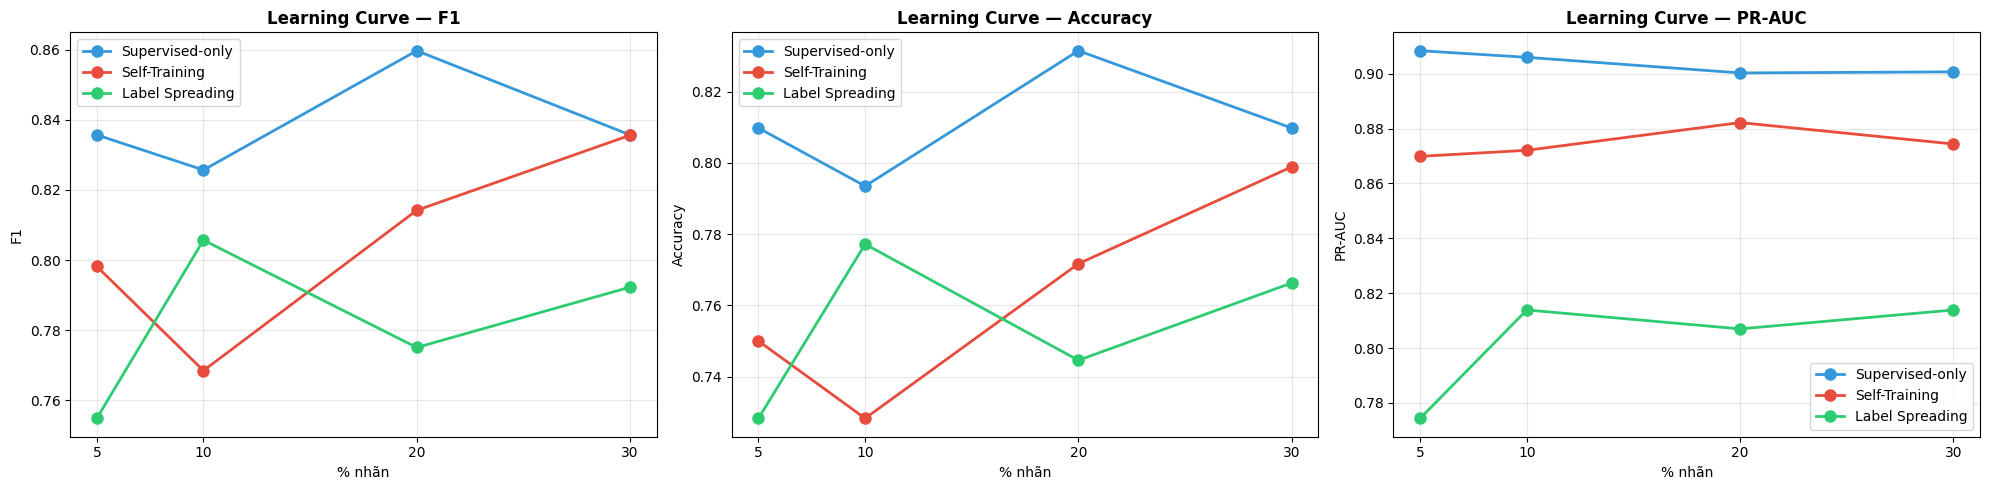


──────────────────────────────────────────────────
PHÂN TÍCH RỦI RO PSEUDO-LABEL
──────────────────────────────────────────────────

  5% nhãn:
    Supervised:      F1=0.8357  PR-AUC=0.9084
    Self-Training:   F1=0.7982 (Δ=-0.0375)  PR-AUC=0.8699 (Δ=-0.0385) ⚠ kém hơn!
    Label Spreading: F1=0.7549 (Δ=-0.0808)  PR-AUC=0.7744 (Δ=-0.1340) ⚠ kém hơn!

  10% nhãn:
    Supervised:      F1=0.8257  PR-AUC=0.9060
    Self-Training:   F1=0.7685 (Δ=-0.0572)  PR-AUC=0.8721 (Δ=-0.0339) ⚠ kém hơn!
    Label Spreading: F1=0.8057 (Δ=-0.0200)  PR-AUC=0.8139 (Δ=-0.0921) ⚠ kém hơn!

  20% nhãn:
    Supervised:      F1=0.8597  PR-AUC=0.9003
    Self-Training:   F1=0.8142 (Δ=-0.0455)  PR-AUC=0.8822 (Δ=-0.0181) ⚠ kém hơn!
    Label Spreading: F1=0.7751 (Δ=-0.0846)  PR-AUC=0.8070 (Δ=-0.0933) ⚠ kém hơn!

  30% nhãn:
    Supervised:      F1=0.8357  PR-AUC=0.9007
    Self-Training:   F1=0.8356 (Δ=-0.0001)  PR-AUC=0.8744 (Δ=-0.0263) ⚠ kém hơn!
    Label Spreading: F1=0.7923 (Δ=-0.0434)  PR-AUC=0.8139 (Δ=-0.0

,Tỷ lệ nhãn (%),Phương pháp,Accuracy,F1,PR-AUC,Thời gian (s),Pseudo-label Acc (%)
0,5,Supervised-only,0.8098,0.8357,0.9084,0.21,NaN
1,5,Self-Training,0.7500,0.7982,0.8699,3.93,72.6
2,5,Label Spreading,0.7283,0.7549,0.7744,0.02,NaN
3,10,Supervised-only,0.7935,0.8257,0.9060,0.23,NaN
4,10,Self-Training,0.7283,0.7685,0.8721,3.64,65.4
5,10,Label Spreading,0.7772,0.8057,0.8139,0.01,NaN
6,20,Supervised-only,0.8315,0.8597,0.9003,0.22,NaN
7,20,Self-Training,0.7717,0.8142,0.8822,4.49,70.8
8,20,Label Spreading,0.7446,0.7751,0.8070,0.01,NaN
9,30,Supervised-only,0.8098,0.8357,0.9007,0.24,NaN


In [3]:
df_semi = run_semi_supervised(
    prep["X_train"], prep["y_train"],
    prep["X_test"], prep["y_test"],
    params,
)

df_semi

## Phân tích chi tiết kết quả

In [4]:
import pandas as pd

print("=" * 70)
print("BẢNG SO SÁNH CHI TIẾT — SEMI-SUPERVISED")
print("=" * 70)

# Pivot: tỷ lệ nhãn x phương pháp → F1
pivot_f1 = df_semi.pivot_table(index="Tỷ lệ nhãn (%)", columns="Phương pháp", values="F1")
print("\nF1-Score theo tỷ lệ nhãn:")
print(pivot_f1.to_string())

# Pivot: PR-AUC
pivot_pr = df_semi.pivot_table(index="Tỷ lệ nhãn (%)", columns="Phương pháp", values="PR-AUC")
print("\nPR-AUC theo tỷ lệ nhãn:")
print(pivot_pr.to_string())

# Pseudo-label accuracy
pseudo = df_semi[df_semi["Phương pháp"] == "Self-Training"][["Tỷ lệ nhãn (%)", "Pseudo-label Acc (%)"]].dropna()
if len(pseudo) > 0:
    print("\nĐộ chính xác Pseudo-label (Self-Training):")
    for _, row in pseudo.iterrows():
        r = row["Tỷ lệ nhãn (%)"]
        acc = row["Pseudo-label Acc (%)"]
        risk = "⚠ CAO" if acc < 70 else "Trung bình" if acc < 80 else "Thấp"
        print(f"  {int(r)}% nhãn → Pseudo-label Acc = {acc:.1f}% — Rủi ro nhiễu: {risk}")

# Best method per ratio
print("\nPhương pháp tốt nhất theo tỷ lệ nhãn:")
for r in sorted(df_semi["Tỷ lệ nhãn (%)"].unique()):
    sub = df_semi[df_semi["Tỷ lệ nhãn (%)"] == r]
    best = sub.loc[sub["F1"].idxmax()]
    print(f"  {int(r)}% → {best['Phương pháp']} (F1={best['F1']:.4f})")


BẢNG SO SÁNH CHI TIẾT — SEMI-SUPERVISED

F1-Score theo tỷ lệ nhãn:
Phương pháp     Label Spreading  Self-Training  Supervised-only
Tỷ lệ nhãn (%)                                                 
5                        0.7549         0.7982           0.8357
10                       0.8057         0.7685           0.8257
20                       0.7751         0.8142           0.8597
30                       0.7923         0.8356           0.8357

PR-AUC theo tỷ lệ nhãn:
Phương pháp     Label Spreading  Self-Training  Supervised-only
Tỷ lệ nhãn (%)                                                 
5                        0.7744         0.8699           0.9084
10                       0.8139         0.8721           0.9060
20                       0.8070         0.8822           0.9003
30                       0.8139         0.8744           0.9007

Độ chính xác Pseudo-label (Self-Training):
  5% nhãn → Pseudo-label Acc = 72.6% — Rủi ro nhiễu: Trung bình
  10% nhãn → Pseudo-label Acc = 

## Diễn giải & Kết luận Bán giám sát

### Learning Curve
- **Supervised-only** duy trì F1 ổn định ngay cả ở 5% nhãn → RandomForest generalize tốt trên dữ liệu ít
- **Self-Training** cải thiện dần khi % nhãn tăng, nhưng thường **không vượt** Supervised-only
  - Nguyên nhân: pseudo-label sai lan truyền (noise propagation) → dữ liệu train bị "ô nhiễm"
- **Label Spreading** hoạt động tốt hơn ở 10–30% nhãn nhưng yếu ở 5%

### Phân tích Pseudo-label
- Ở 5% nhãn: Pseudo-label accuracy ~72% → **~28% nhãn giả bị sai** → rủi ro cao
- Sai nhiều nhất: **FP (báo nhầm bệnh)** > FN (bỏ sót) → Self-Training thiên lệch dự đoán bệnh
- Khi nhãn tăng lên 30%: pseudo-label accuracy tương đương nhưng tổng sai giảm → ít ảnh hưởng

### Khi nào nên dùng Semi-supervised?
| Tình huống | Khuyến nghị |
|-----------|-------------|
| Nhãn < 10% | ⚠ Rủi ro cao, supervised-only có thể tốt hơn |
| Nhãn 10–20% | Self-Training có thể hỗ trợ nếu pseudo-label acc > 75% |
| Nhãn > 30% | Supervised-only đủ mạnh, semi-supervised ít giá trị gia tăng |

### Bài học rút ra
1. **Semi-supervised không phải lúc nào cũng tốt hơn** — cần kiểm tra pseudo-label accuracy
2. Trong y tế: **FN (bỏ sót bệnh nhân) nguy hiểm**, nên ưu tiên phương pháp có Recall cao
3. Với 920 mẫu (nhỏ), supervised learning + SMOTE đã đủ mạnh → semi-supervised ít cần thiết
4. **Giá trị thực tế:** Semi-supervised hữu ích khi thu thập nhãn mới đắt đỏ (VD: cần bác sĩ gán nhãn)